# Heart Disease UCI - Exploratory Data Analysis

**Goal:** understand the dataset before building any preprocessing or model - check data quality
(missing values, weird types), look at how features relate to the target, and spot anything
that will need special handling later (outliers, imbalance, multi-site differences).

**Source:** combined UCI Heart Disease dataset (Cleveland, Hungary, Switzerland, VA Long Beach),
~920 patients, 14 clinical attributes + target.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the data

In [2]:
df = pd.read_csv("../data/raw/heart_disease_uci.csv")
print(df.shape)
df.head()


(920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


`id` and `dataset` are not clinical features:
- `id` is just a row identifier - useless for modeling, will be dropped later.
- `dataset` tells us *which hospital/site* the record came from (Cleveland, Hungary, Switzerland,
  VA Long Beach). We keep it for now because it's very useful during EDA - different sites used
  different equipment and have very different missing-data patterns, as we'll see below.


## 2. Structure and data types

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


A few things to flag immediately:
- `fbs` and `exang` are boolean (`TRUE`/`FALSE`) but pandas may read them as `object` - need to
  convert to real booleans/ints during preprocessing.
- `cp`, `restecg`, `slope`, `thal`, `sex`, `dataset` are categorical strings - will need encoding.
- `num` is the target, but it's **not binary** - it ranges 0-4 (0 = no disease, 1-4 = increasing
  severity). For a "risk predictor" framing, we'll binarize it later: `0` stays `0` (healthy),
  `1-4` becomes `1` (has heart disease). We keep the original `num` in this notebook to see the
  full severity distribution first.


## 3. Missing values

This is the most important check before anything else - missing data will directly shape our
preprocessing strategy (drop columns? impute? and with what?).


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count,missing_pct
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
thalch,55,6.0
exang,55,6.0
chol,30,3.3
restecg,2,0.2


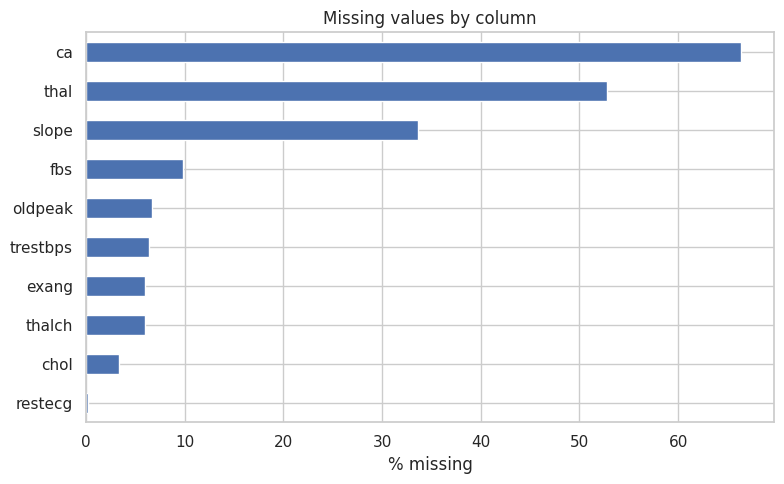

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
missing_summary["missing_pct"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()


**Why this matters:** `ca` and `thal` are missing in a large chunk of rows, and `slope` too.
If these turn out to be missing *at random*, simple imputation (median/mode) is fine. But if the
missingness is tied to *which hospital* collected the data, that's "missing not at random" and
naive imputation could quietly bias the model. Let's check that next.


In [6]:
missing_by_site = df.groupby("dataset")[["trestbps", "chol", "fbs", "restecg", "thalch",
                                            "exang", "oldpeak", "slope", "ca", "thal"]].apply(
    lambda g: g.isnull().mean() * 100
).round(1)
missing_by_site


,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
dataset,,,,,,,,,,
Cleveland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,1.6,1.0
Hungary,0.3,7.8,2.7,0.3,0.3,0.3,0.0,64.5,99.0,90.4
Switzerland,1.6,0.0,61.0,0.8,0.8,0.8,4.9,13.8,95.9,42.3
VA Long Beach,28.0,3.5,3.5,0.0,26.5,26.5,28.0,51.0,99.0,83.0


**Insight:** missingness is *not* random across sites. `ca` is missing in ~99% of the Hungary
and VA Long Beach records and ~96% of Switzerland's, and `thal` is missing in 90%+ of Hungary and
VA Long Beach too - while Cleveland has almost no gaps in either. `slope` follows a similar pattern
(missing in over half of Hungary and VA). This confirms the "missing not at random" concern - those
sites likely didn't run the same battery of tests. This is useful context for the preprocessing
phase: dropping `ca`/`thal` entirely is one valid option; per-site imputation is another. We'll make
that call explicitly in `data_processing.py` instead of silently imputing with the global median.


## 4. Target variable

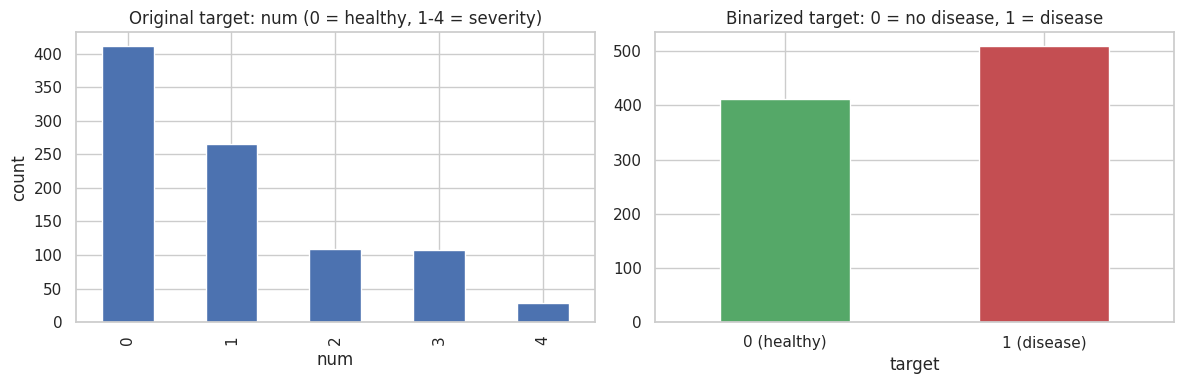

target
1    0.553
0    0.447
Name: proportion, dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["num"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Original target: num (0 = healthy, 1-4 = severity)")
axes[0].set_xlabel("num", rotation=0)
axes[0].set_ylabel("count")

df["target"] = (df["num"] > 0).astype(int)
df["target"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("Binarized target: 0 = no disease, 1 = disease")
axes[1].set_xticklabels(["0 (healthy)", "1 (disease)"], rotation=0)

plt.tight_layout()
plt.show()

df["target"].value_counts(normalize=True).round(3)


**Why binarize:** the business question is "is this patient at risk of heart disease or not",
not "which of 5 severity grades". Binarizing also gives us a much more standard, better-understood
classification setup (and simplifies choosing metrics later). The class split isn't drastically
imbalanced (roughly 55/45), so we likely won't need heavy resampling techniques - but we'll confirm
that formally once we do the train/test split.


## 5. Numeric feature distributions

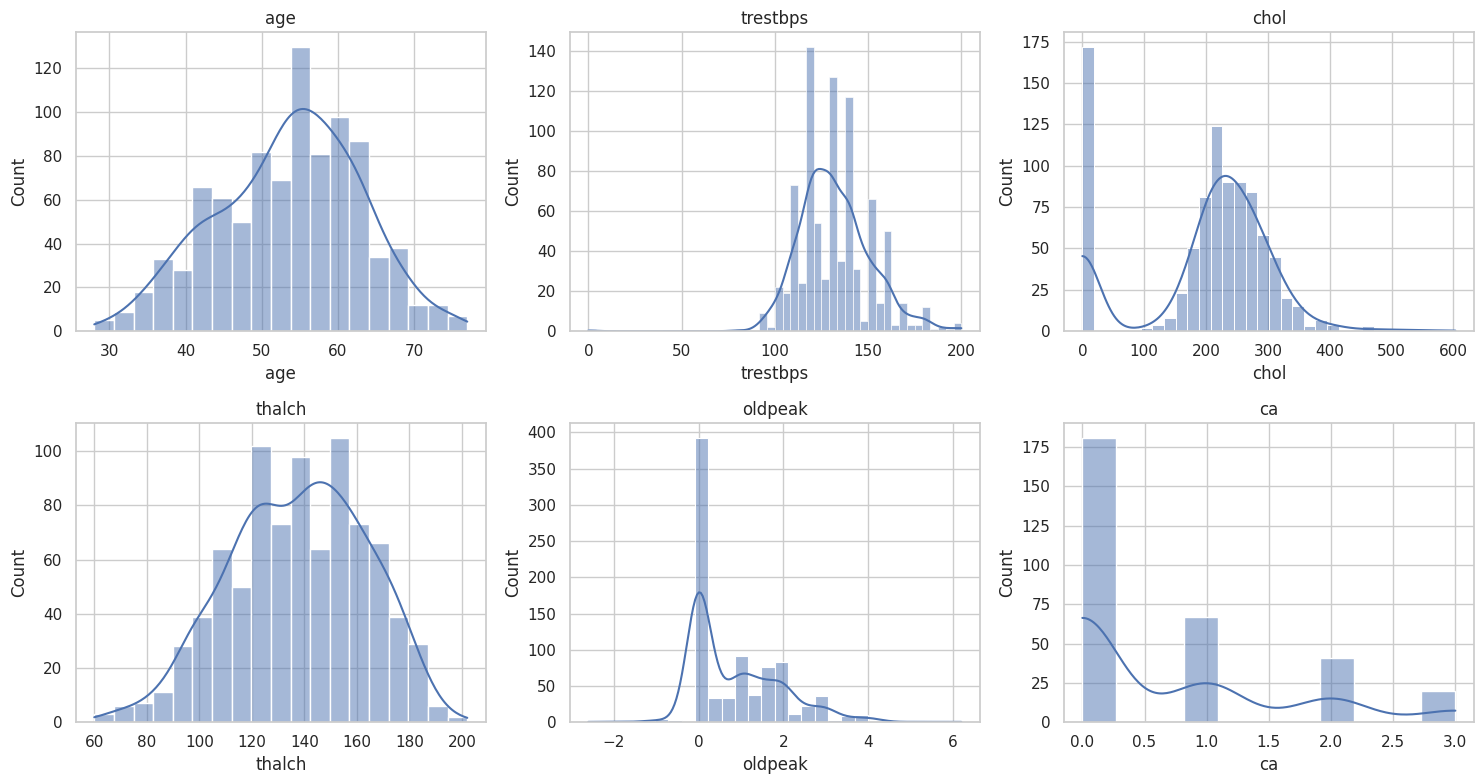

,age,trestbps,chol,thalch,oldpeak,ca
count,920.00,861.00,890.00,865.00,858.00,309.00
mean,53.51,132.13,199.13,137.55,0.88,0.68
std,9.42,19.07,110.78,25.93,1.09,0.94
min,28.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,175.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,140.00,0.50,0.00
75%,60.00,140.00,268.00,157.00,1.50,1.00
max,77.00,200.00,603.00,202.00,6.20,3.00


In [8]:
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

df[numeric_cols].describe().round(2)


A few quick reads:
- `chol` (cholesterol) has a suspicious spike at **0** - around 170 rows, which is almost certainly
  a missing-value placeholder rather than a real reading (nobody has 0 cholesterol). Needs to be
  treated as missing, not as a real low value.
- `trestbps` (resting blood pressure) has one row with the same issue - worth the same fix, even
  though it's a single row.
- `oldpeak` (ST depression) is right-skewed with a chunk of patients at 0 - clinically plausible
  (many patients show no ST depression).
- `age` looks roughly normal, centered in the 50s-60s, consistent with a cardiac-risk population.


In [9]:
print("Rows with chol == 0:", (df["chol"] == 0).sum())
print("Rows with trestbps == 0:", (df["trestbps"] == 0).sum())


Rows with chol == 0: 172
Rows with trestbps == 0: 1


## 6. Outlier detection

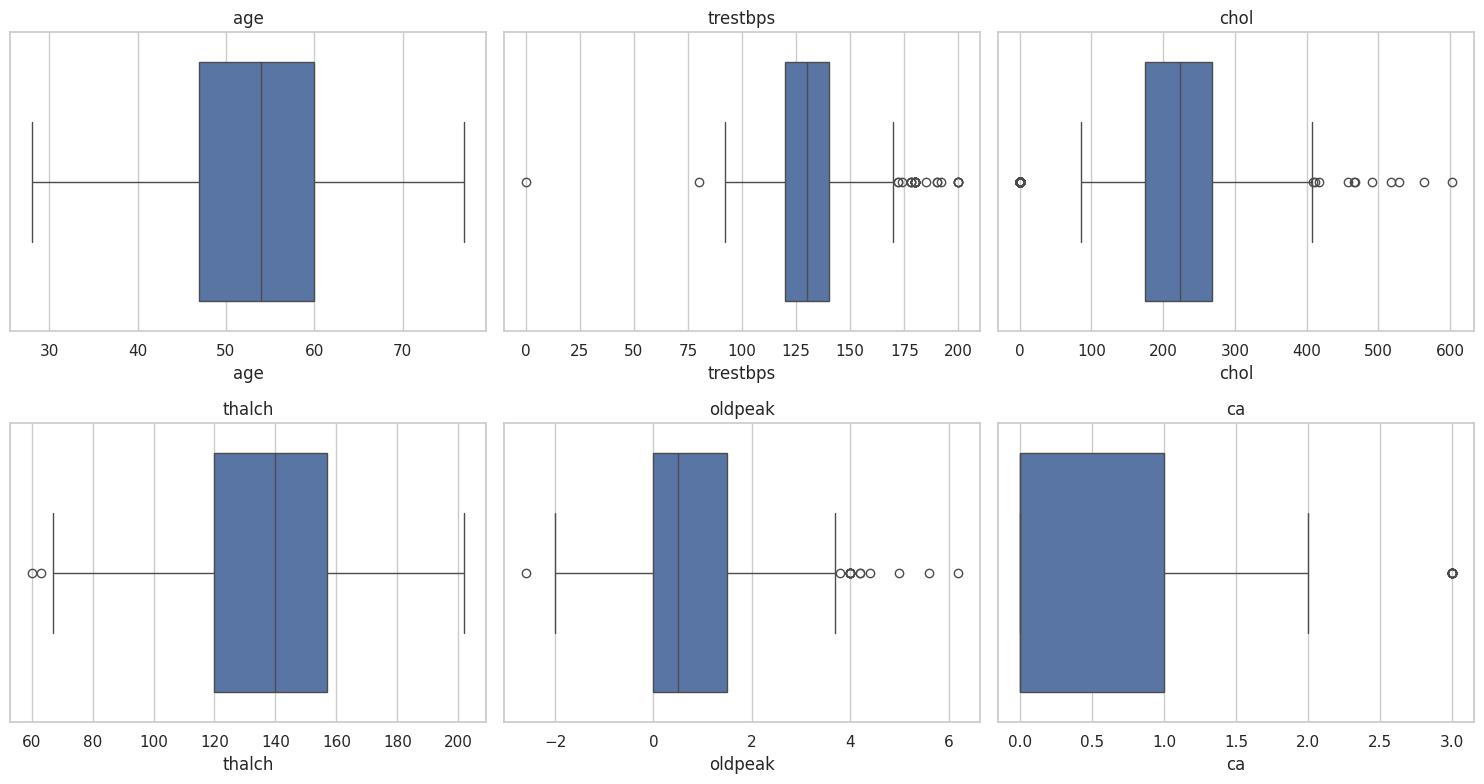

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


`chol` and `trestbps` show extreme outliers on the high end (e.g. cholesterol > 500) alongside
the 0-placeholders on the low end - both ends need attention. `thalch` (max heart rate) has a
low-end outlier or two, plausible for a resting/sick patient. We won't aggressively remove outliers
here - tree-based models (Random Forest, XGBoost) are fairly robust to them - but we will fix the
0-placeholder issue in preprocessing since that's a data-quality bug, not a genuine extreme value.


## 7. Correlations with the target

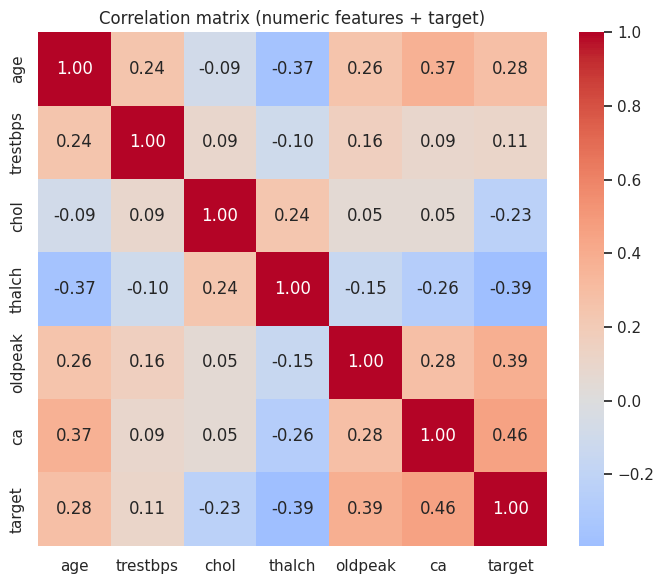

In [11]:
corr_cols = numeric_cols + ["target"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()


**Reading correlations with `target`:**
- `thalch` (max heart rate achieved) correlates *negatively* - lower max heart rate during exercise
  associates with higher disease risk. Makes physiological sense (reduced cardiac capacity).
- `oldpeak` and `ca` correlate *positively* and fairly strongly - more ST depression and more major
  vessels affected are both classic markers of disease severity.
- `age` has a moderate positive correlation, as expected. `trestbps` (resting blood pressure) is
  the surprise here - its correlation with the target is close to zero, weaker than its reputation
  as a classic risk factor would suggest. That's a good reminder that Pearson correlation only
  catches *linear* relationships. Categorical features (`cp`, `thal`, `sex`) might matter a lot too,
  despite not showing up here at all, since they can't be correlated this way without encoding
  first - checked separately below.


## 8. Categorical features vs. target

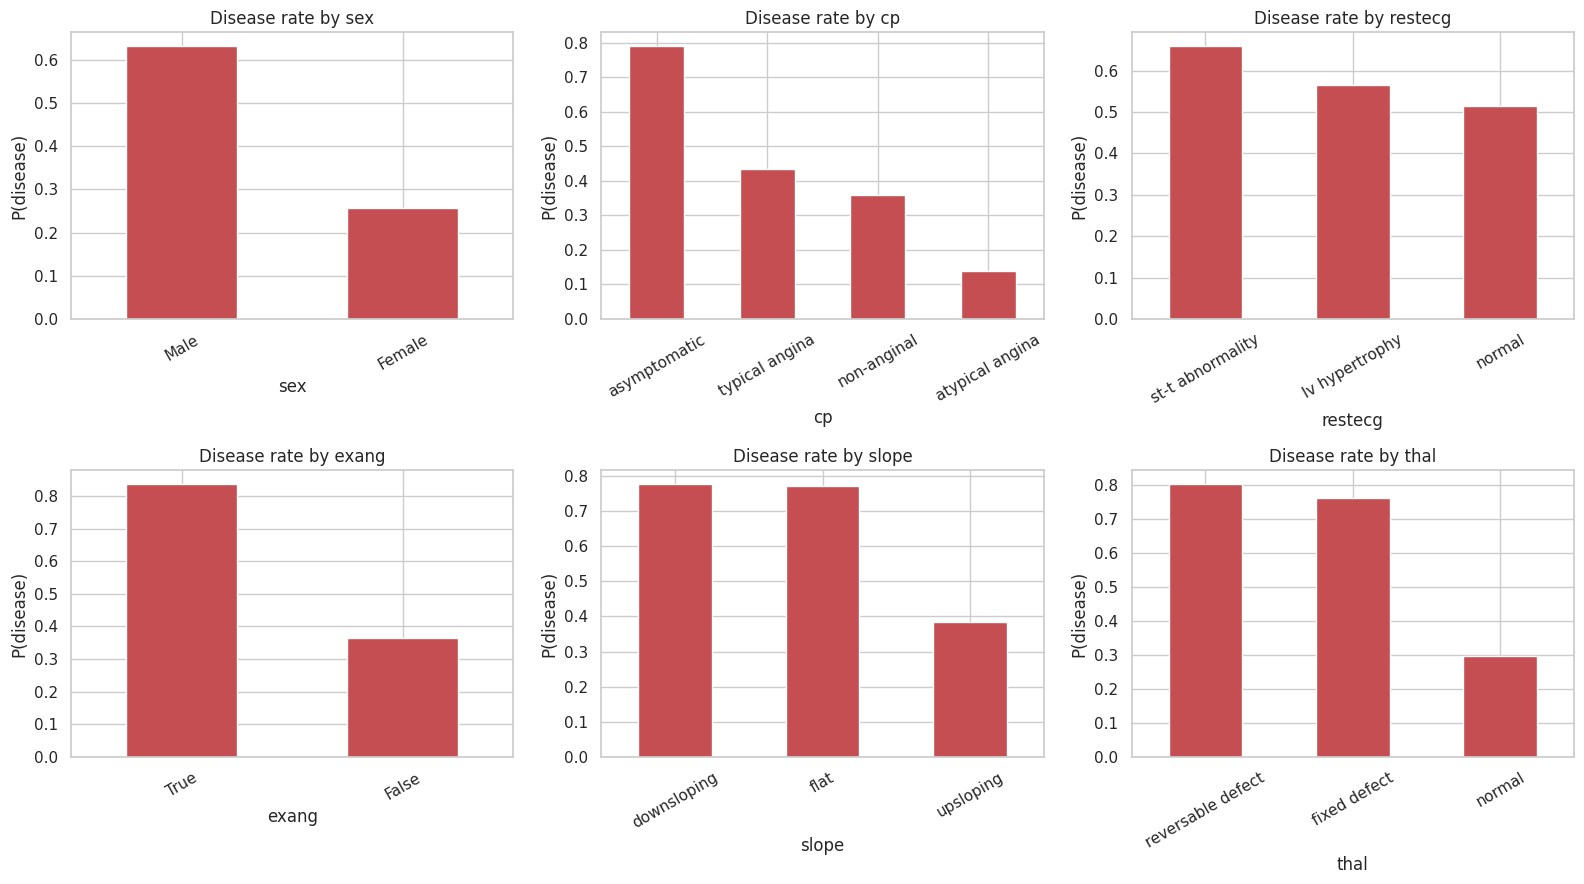

In [12]:
categorical_cols = ["sex", "cp", "restecg", "exang", "slope", "thal"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(categorical_cols, axes.flatten()):
    rate = df.groupby(col)["target"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Disease rate by {col}")
    ax.set_ylabel("P(disease)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Standouts:**
- `cp` (chest pain type): patients with *asymptomatic* chest pain have a much **higher** disease
  rate than those with typical/atypical angina - counterintuitive at first, but well documented
  clinically (silent/asymptomatic presentation is itself a risk marker, not a reassuring sign).
- `exang` (exercise-induced angina): patients who report it have a clearly higher disease rate -
  matches medical intuition directly.
- `sex`: disease rate differs noticeably between male and female patients in this dataset (roughly
  63% vs 26%) - a strong effect, though worth remembering the dataset itself is majority male, so
  this split may partly reflect who ended up in the study, not just biology.
- `thal`: both "fixed defect" and "reversable defect" show a much higher disease rate (~76-80%)
  than "normal" (~30%) - makes clinical sense, since both describe an abnormal thallium stress
  test result.

These categorical features look at least as informative as the numeric ones - confirms we need
proper categorical encoding in preprocessing, not just dropping them.


## 9. Summary of key insights for modeling

1. **Missingness is site-driven, not random** (`ca`, `thal`, `slope` missing mostly in
   Switzerland/VA data) - needs a deliberate strategy, not blind global imputation.
2. **`chol` and `trestbps` contain 0-value placeholders** for missing data - must be converted to
   real NaNs before imputation, otherwise the model learns a nonsensical "0 cholesterol" pattern.
3. **Target is roughly balanced** (~55/45 after binarizing `num`) - no urgent need for resampling
   (e.g. SMOTE), but worth re-checking after the train/test split.
4. **Both numeric and categorical features carry signal** - `oldpeak`, `ca`, `thalch` numerically;
   `cp`, `exang`, `thal` categorically. Preprocessing needs to handle both properly (scaling +
   encoding), not just one or the other.
5. **Outliers exist but aren't extreme enough to justify row removal** - tree-based models should
   handle them fine; we'll keep this in mind if we also try a linear model like Logistic Regression,
   which is more sensitive to them.

Next step: `src/data_processing.py` - turn these findings into a reproducible cleaning +
feature-engineering pipeline.
